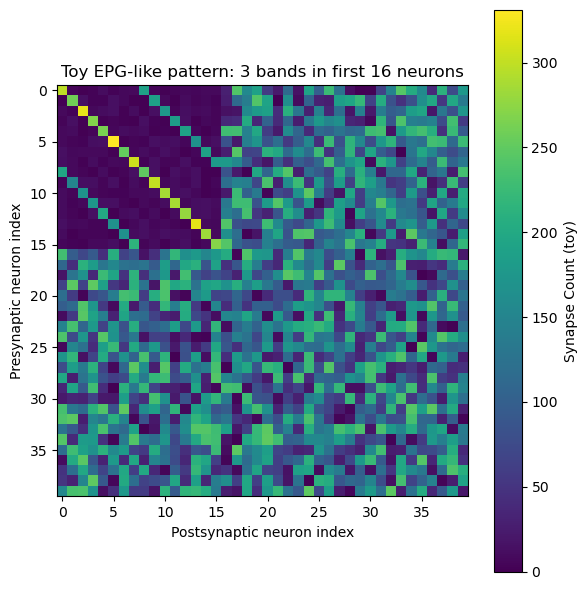

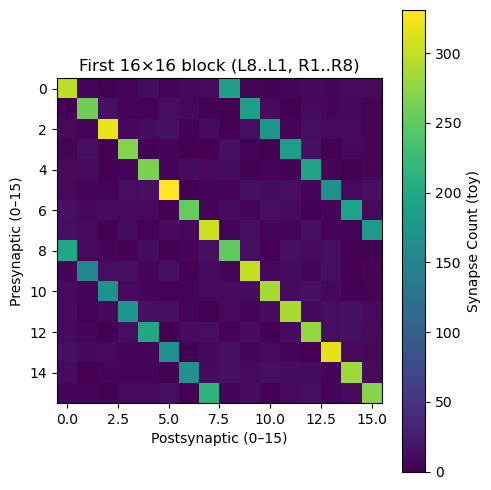

W shape: (40, 40)


In [1]:
import numpy as np
import matplotlib.pyplot as plt

def generate_test_W():

    np.random.seed(0)

    # -----------------------------
    # 參數設定
    # -----------------------------
    N_pattern = 16          # 前 16 個 neuron 有特殊 pattern
    N_total   = 40          # 總 neuron 數量（可改）

    # 建立整體矩陣，先放小一點的背景噪聲
    W = np.random.randint(0, 15, size=(N_total, N_total))

    # -----------------------------
    # 前 16 個 neuron 的編號：
    # 0..7  : L8, L7, ..., L1
    # 8..15 : R1, R2, ..., R8
    # 要做：
    #  - 每個 neuron 強連到自己（主對角線 band）
    #  - Lk -> R(對應), R -> L(對應)（兩條對稱 off-diagonal）
    # -----------------------------

    for i in range(8):
        idx_L = i          # L8..L1
        idx_R = 8 + i      # R1..R8

        # 自己 → 自己（主對角線）
        W[idx_L, idx_L] = np.random.randint(250, 340)   # L 自身
        W[idx_R, idx_R] = np.random.randint(250, 340)   # R 自身

        # L ↔ R 對應（形成上下兩條 band）
        w_L_to_R = np.random.randint(140, 230)
        w_R_to_L = np.random.randint(140, 230)

        W[idx_L, idx_R] = w_L_to_R   # L -> R
        W[idx_R, idx_L] = w_R_to_L   # R -> L

    # （可選）把非 pattern 區塊的值壓小一點，讓 band 更明顯
    background_mask = np.ones_like(W, dtype=bool)
    background_mask[:N_pattern, :N_pattern] = False
    W[background_mask] = np.random.randint(0, 250, size=W[background_mask].shape)

    # -----------------------------
    # 畫出整體矩陣
    # -----------------------------
    plt.figure(figsize=(6, 6))
    plt.imshow(W, interpolation='nearest')
    plt.colorbar(label="Synapse Count (toy)")
    plt.title("Toy EPG-like pattern: 3 bands in first 16 neurons")
    plt.xlabel("Postsynaptic neuron index")
    plt.ylabel("Presynaptic neuron index")
    plt.tight_layout()
    plt.show()

    # 如果你只想看前 16x16 區塊，也可以：
    plt.figure(figsize=(5, 5))
    plt.imshow(W[:N_pattern, :N_pattern], interpolation='nearest')
    plt.colorbar(label="Synapse Count (toy)")
    plt.title("First 16×16 block (L8..L1, R1..R8)")
    plt.xlabel("Postsynaptic (0–15)")
    plt.ylabel("Presynaptic (0–15)")
    plt.tight_layout()
    plt.show()


    return W

# --- 產生一個 80x80 的測試矩陣 ---
W = generate_test_W()
print("W shape:", W.shape)


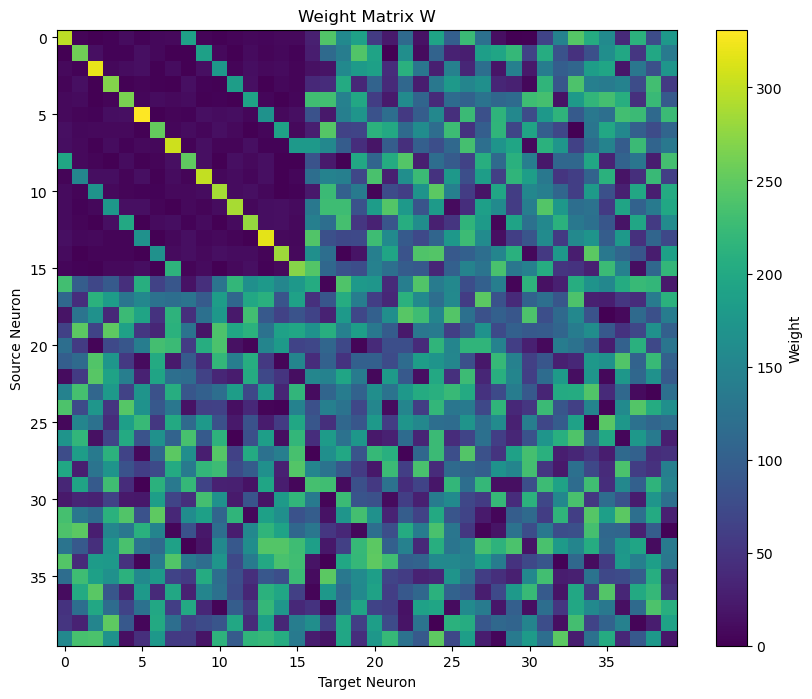

In [2]:
import matplotlib.pyplot as plt

# Plot the weight matrix W
plt.figure(figsize=(10, 8))
plt.imshow(W, cmap='viridis', aspect='auto')
plt.colorbar(label='Weight')
plt.title('Weight Matrix W')
plt.xlabel('Target Neuron')
plt.ylabel('Source Neuron')
plt.show()


In [3]:
import numpy as np
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import pdist

def blind_sort(W):
    # W: (N, N) adjacency / weight matrix
    # 假設 W[i, j] = i → j 的 synaptic weight

    N = W.shape[0]

    # 1) outgoing + incoming 都當成 feature（可以視情況調整）
    outgoing = W              # shape (N, N)
    incoming = W.T            # shape (N, N)

    # concat 成一個 2N 維的向量
    features = np.concatenate([outgoing, incoming], axis=1)  # (N, 2N)

    # 避免 scale 差太多，做個 normalization
    norm = np.linalg.norm(features, axis=1, keepdims=True) + 1e-8
    features_norm = features / norm

    # 用 cosine 距離或歐式距離都可以，視你資料而定
    distance_vec = pdist(features_norm, metric='cosine')
    Z = linkage(distance_vec, method='ward')   # 做階層式分群

    # 取得樹狀圖葉子的順序，就是新的 index 排列
    perm = leaves_list(Z)   # shape (N,)

    W_sorted = W[perm][:, perm]
    
    return W_sorted, perm

import numpy as np
from scipy.sparse.csgraph import laplacian
from scipy.linalg import eigh

def spectral_sort(W):
    """
    Uses the Fiedler vector of the Graph Laplacian to seriate the matrix.
    This puts connected nodes next to each other, recovering diagonal structures.
    """
    N = W.shape[0]
    
    # 1. Symmetrize the matrix (make it an undirected graph for Laplacian)
    W_sym = 0.5 * (W + W.T)
    
    # 2. Compute the Graph Laplacian
    # L = Degree_Matrix - Adjacency_Matrix
    L = laplacian(W_sym, normed=False)
    
    # 3. Compute Eigenvalues and Eigenvectors
    # We want the eigenvector associated with the 2nd smallest eigenvalue (Fiedler vector)
    evals, evecs = eigh(L)
    
    # The 0th eigenvalue is approx 0. The 1st is the Fiedler value.
    fiedler_vec = evecs[:, 1]
    
    # 4. The values in the Fiedler vector define the 'position' on the line
    perm = np.argsort(fiedler_vec)
    
    W_sorted = W[perm][:, perm]
    
    return W_sorted, perm

def degree_sort(W):
    """
    Sorts the matrix based on total node degree (sum of incoming + outgoing weights).
    This pushes the 'dense' cluster to the top-left.
    """
    # Calculate total strength (in-degree + out-degree)
    degrees = np.sum(W, axis=1) + np.sum(W, axis=0)
    
    # Sort indices in descending order (Strongest nodes first)
    perm = np.argsort(degrees)[::-1]
    
    W_sorted = W[perm][:, perm]
    return W_sorted, perm

import numpy as np
from scipy.sparse.csgraph import laplacian
from scipy.linalg import eigh

def robust_sort(W):
    """
    Recovers the initial structure by separating the signal from the noise
    before sorting.
    
    1. Separates 'Active' neurons (signal) from 'Silent' ones (noise) using degree.
    2. Uses Spectral Seriation (Fiedler vector) ONLY on the Active block to recover the diagonal.
    3. Stacks them back together.
    """
    N = W.shape[0]
    
    # --- Step 1: Isolate the Active Core ---
    # Calculate node strength (degree)
    degrees = np.sum(W, axis=1) + np.sum(W, axis=0)
    
    # Threshold: Define "Active" as nodes with above-average connectivity
    # (You can tune this threshold, e.g., mean, median, or a percentile)
    threshold = np.mean(degrees)
    
    active_idx = np.where(degrees > threshold)[0]
    silent_idx = np.where(degrees <= threshold)[0]
    
    # --- Step 2: Spectral Sort the Active Core ONLY ---
    if len(active_idx) > 1:
        # Extract the submatrix of active neurons
        W_core = W[np.ix_(active_idx, active_idx)]
        
        # Symmetrize for Laplacian
        W_sym = 0.5 * (W_core + W_core.T)
        
        # Compute Laplacian and Fiedler Vector (2nd smallest eigenvector)
        L = laplacian(W_sym, normed=True) # Normed often works better for seriation
        evals, evecs = eigh(L)
        
        # The Fiedler vector is usually the second eigenvector (index 1)
        # (index 0 is constant for connected graphs)
        fiedler_vec = evecs[:, 1]
        
        # Sort the active indices based on their position in the Fiedler vector
        core_perm = np.argsort(fiedler_vec)
        sorted_active_idx = active_idx[core_perm]
        
        # OPTIONAL: Flip if the diagonal is "anti-diagonal" (running / instead of \)
        # We check if the bandwidth is smaller in the current order or reversed order
        W_test = W_core[core_perm][:, core_perm]
        if np.trace(W_test) < np.trace(np.flip(W_test, axis=0)):
             sorted_active_idx = sorted_active_idx[::-1]
             
    else:
        sorted_active_idx = active_idx

    # --- Step 3: Combine ---
    # Put Active nodes first (Top-Left), Silent nodes last
    final_perm = np.concatenate([sorted_active_idx, silent_idx])
    
    W_sorted = W[final_perm][:, final_perm]
    
    return W_sorted, final_perm



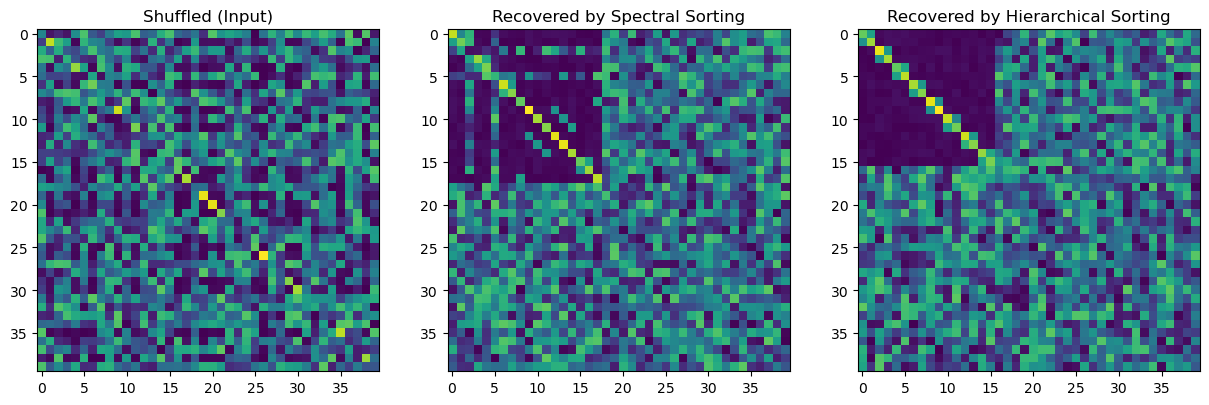

In [9]:
from sklearn.cluster import SpectralCoclustering
import numpy as np
import scipy.cluster.hierarchy as sch

def sort_matrix_spectral(W):
    # 假設 W 是非負的
    # 使用 Spectral Co-clustering 找回結構
    model = SpectralCoclustering(n_clusters=2, random_state=0)
    model.fit(W)
    
    # 取得排序後的索引
    fit_idx = np.argsort(model.row_labels_)
    W_sorted = W[fit_idx, :][:, fit_idx]
    
    return W_sorted, fit_idx


def sort_matrix_hierarchical(W):
    # 計算相關性距離矩陣
    # 我們將每一列視為一個神經元的「特徵向量」
    d = sch.distance.pdist(W)
    L = sch.linkage(d, method='ward')
    
    # 取得葉節點排序
    ind = sch.leaves_list(L)
    
    # 重新排列矩陣
    W_sorted = W[ind, :][:, ind]
    return W_sorted, ind

# 測試：先將你原本的 W 隨機打亂
N = W.shape[0]
shuffled_idx = np.random.permutation(N)
W_shuffled = W[shuffled_idx, :][:, shuffled_idx]

# 重新排序
W_recovered, recovered_idx = sort_matrix_spectral(W_shuffled)
W_recovered_hierarchical, recovered_idx_hierarchical = sort_matrix_hierarchical(W_shuffled)

# 繪圖比較
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(W_shuffled)
plt.title("Shuffled (Input)")
plt.subplot(1, 3, 2)
plt.imshow(W_recovered)
plt.title("Recovered by Spectral Sorting")
plt.subplot(1, 3, 3)
plt.imshow(W_recovered_hierarchical)
plt.title("Recovered by Hierarchical Sorting")
plt.show()

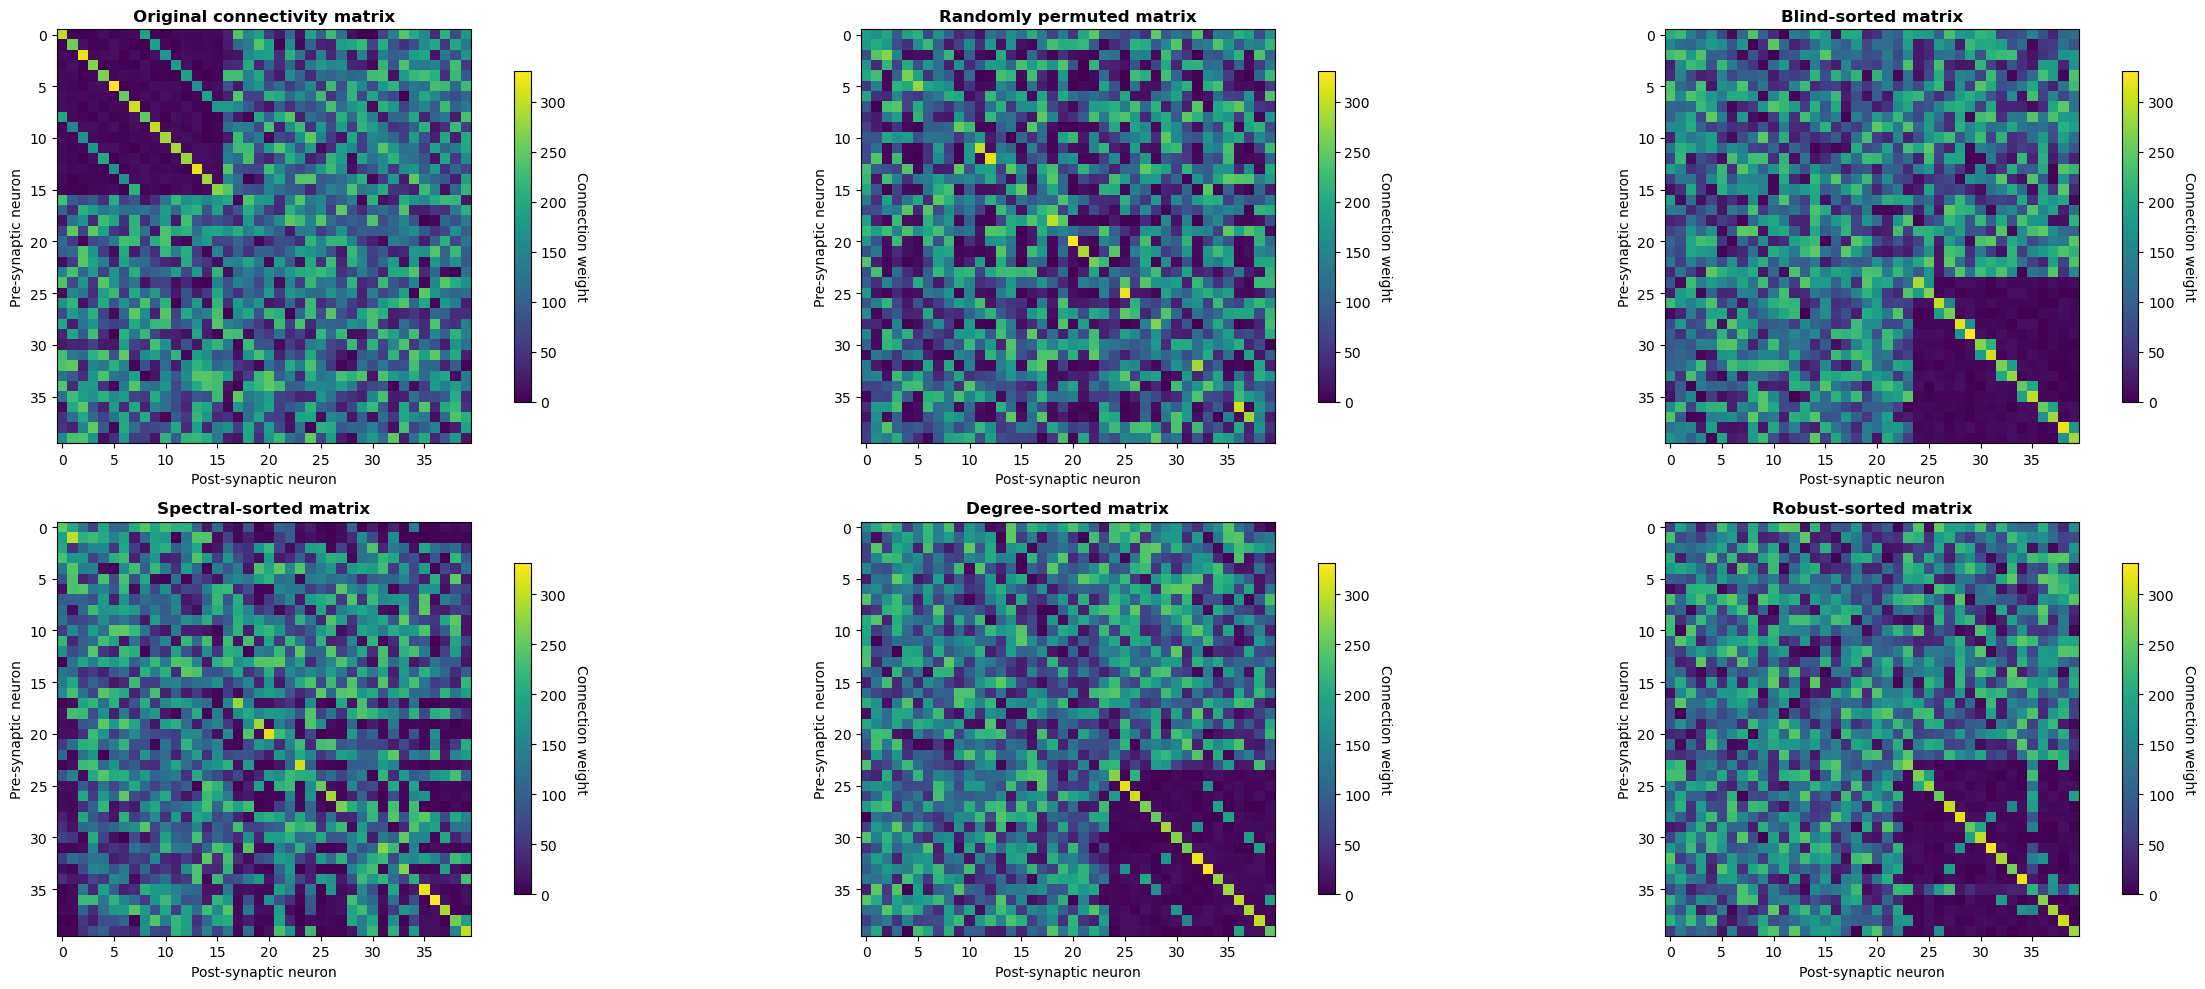

Sorting Algorithm Comparison:
--------------------------------------------------
Original matrix shape: (40, 40)
Random permutation applied: 40 neurons shuffled

Sorting results:
- Blind sort: 40 neurons reordered
- Spectral sort: 40 neurons reordered
- Degree sort: 40 neurons reordered
- Robust sort: 40 neurons reordered


In [4]:
import matplotlib.pyplot as plt

# Set random seed for reproducibility
np.random.seed(42)
random_perm = np.random.permutation(W.shape[0])
W_random = W[random_perm][:, random_perm]

# Apply different sorting algorithms to the randomly permuted matrix
W_sorted, perm = blind_sort(W_random)
W_spectral_sorted, spectral_perm = spectral_sort(W_random)
W_degree_sorted, degree_perm = degree_sort(W_random)
W_robust_sorted, robust_perm = robust_sort(W_random)

# Create comprehensive comparison plot
fig, axes = plt.subplots(2, 3, figsize=(25, 10))
axes = axes.flatten()

# Define plot configurations
plot_configs = [
    (W, "Original connectivity matrix"),
    (W_random, "Randomly permuted matrix"),
    (W_sorted, "Blind-sorted matrix"),
    (W_spectral_sorted, "Spectral-sorted matrix"),
    (W_degree_sorted, "Degree-sorted matrix"),
    (W_robust_sorted, "Robust-sorted matrix")
]

# Plot each matrix
for idx, (matrix, title) in enumerate(plot_configs):
    im = axes[idx].imshow(matrix, interpolation='nearest', cmap='viridis')
    axes[idx].set_title(title, fontsize=12, fontweight='bold')
    axes[idx].set_xlabel("Post-synaptic neuron")
    axes[idx].set_ylabel("Pre-synaptic neuron")
    
    # Add colorbar for each subplot
    cbar = plt.colorbar(im, ax=axes[idx], shrink=0.8)
    cbar.set_label("Connection weight", rotation=270, labelpad=15)

plt.tight_layout()
plt.show()

# Print sorting performance metrics
print("Sorting Algorithm Comparison:")
print("-" * 50)
print(f"Original matrix shape: {W.shape}")
print(f"Random permutation applied: {len(random_perm)} neurons shuffled")
print("\nSorting results:")
print(f"- Blind sort: {len(perm)} neurons reordered")
print(f"- Spectral sort: {len(spectral_perm)} neurons reordered") 
print(f"- Degree sort: {len(degree_perm)} neurons reordered")
print(f"- Robust sort: {len(robust_perm)} neurons reordered")


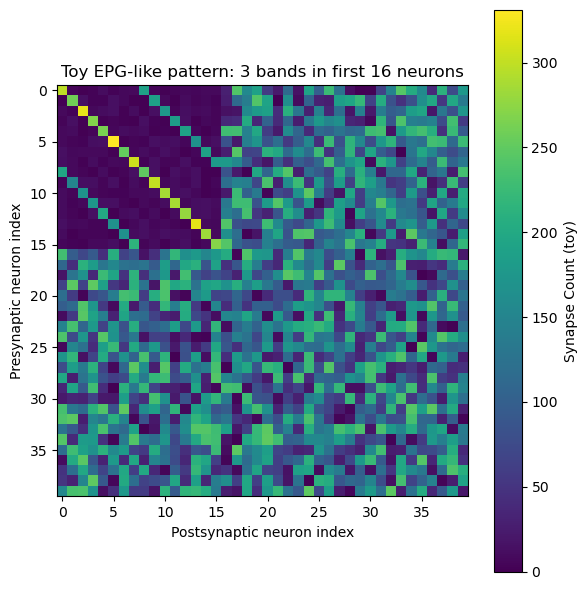

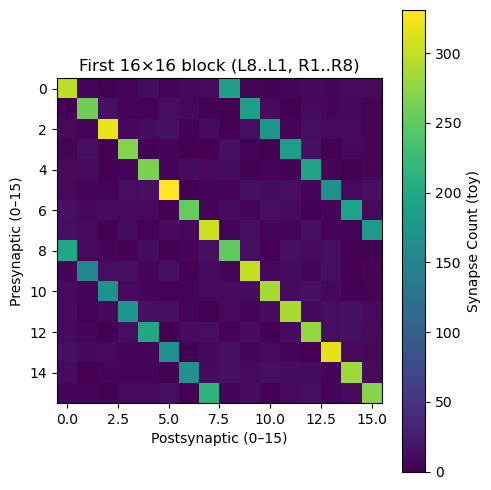

In [5]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

# -----------------------------
# 參數設定
# -----------------------------
N_pattern = 16          # 前 16 個 neuron 有特殊 pattern
N_total   = 40          # 總 neuron 數量（可改）

# 建立整體矩陣，先放小一點的背景噪聲
W = np.random.randint(0, 15, size=(N_total, N_total))

# -----------------------------
# 前 16 個 neuron 的編號：
# 0..7  : L8, L7, ..., L1
# 8..15 : R1, R2, ..., R8
# 要做：
#  - 每個 neuron 強連到自己（主對角線 band）
#  - Lk -> R(對應), R -> L(對應)（兩條對稱 off-diagonal）
# -----------------------------

for i in range(8):
    idx_L = i          # L8..L1
    idx_R = 8 + i      # R1..R8

    # 自己 → 自己（主對角線）
    W[idx_L, idx_L] = np.random.randint(250, 340)   # L 自身
    W[idx_R, idx_R] = np.random.randint(250, 340)   # R 自身

    # L ↔ R 對應（形成上下兩條 band）
    w_L_to_R = np.random.randint(140, 230)
    w_R_to_L = np.random.randint(140, 230)

    W[idx_L, idx_R] = w_L_to_R   # L -> R
    W[idx_R, idx_L] = w_R_to_L   # R -> L

# （可選）把非 pattern 區塊的值壓小一點，讓 band 更明顯
background_mask = np.ones_like(W, dtype=bool)
background_mask[:N_pattern, :N_pattern] = False
W[background_mask] = np.random.randint(0, 250, size=W[background_mask].shape)

W_pattern = W[:N_pattern, :N_pattern]
# -----------------------------
# 畫出整體矩陣
# -----------------------------
plt.figure(figsize=(6, 6))
plt.imshow(W, interpolation='nearest')
plt.colorbar(label="Synapse Count (toy)")
plt.title("Toy EPG-like pattern: 3 bands in first 16 neurons")
plt.xlabel("Postsynaptic neuron index")
plt.ylabel("Presynaptic neuron index")
plt.tight_layout()
plt.show()

# 如果你只想看前 16x16 區塊，也可以：
plt.figure(figsize=(5, 5))
plt.imshow(W_pattern, interpolation='nearest')
plt.colorbar(label="Synapse Count (toy)")
plt.title("First 16×16 block (L8..L1, R1..R8)")
plt.xlabel("Postsynaptic (0–15)")
plt.ylabel("Presynaptic (0–15)")
plt.tight_layout()
plt.show()


Best match top-left at (row=23, col=23), NCC=0.6426, pattern size=(16, 16)


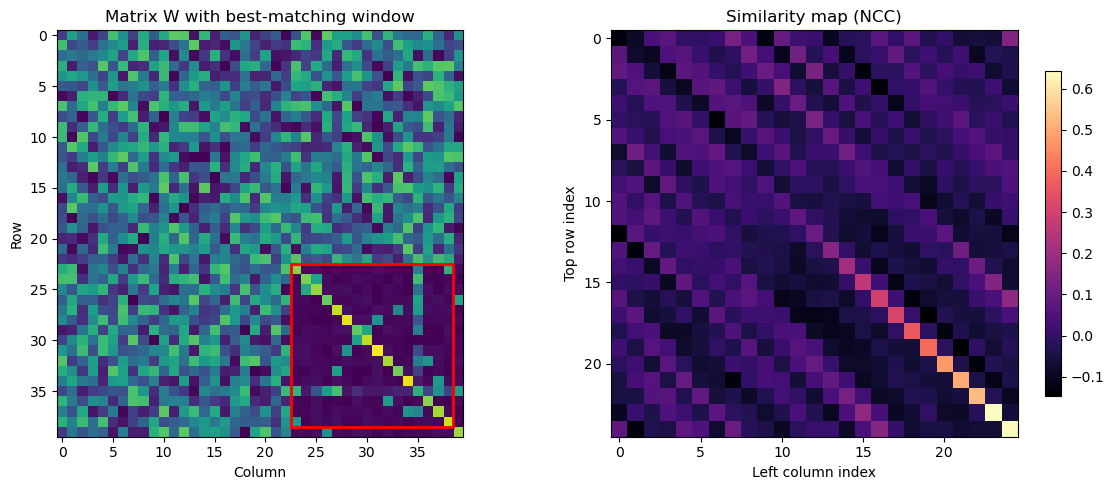

In [6]:
import numpy as np
from numpy.lib.stride_tricks import sliding_window_view
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle


def find_best_submatrix(image: np.ndarray,
                        pattern: np.ndarray,
                        method: str = "ncc",
                        return_map: bool = True,
                        eps: float = 1e-12):
    """
    Find the top-left coordinate of the submatrix in `image` that best matches `pattern`.

    - method="ncc": normalized cross-correlation in [-1, 1]; higher is more similar
    - method="ssd": negative sum of squared differences; higher (less negative) is more similar

    Returns:
        (top, left, best_score, best_patch, score_map [optional])
    """
    image = np.asarray(image, dtype=np.float64)
    pattern = np.asarray(pattern, dtype=np.float64)

    if image.ndim != 2 or pattern.ndim != 2:
        raise ValueError("Both `image` and `pattern` must be 2D arrays.")

    H, W = image.shape
    h, w = pattern.shape
    if h > H or w > W:
        raise ValueError("`pattern` must be smaller than or equal to `image` in both dimensions.")

    # Sliding window view over the image to compare every h×w patch
    windows = sliding_window_view(image, (h, w))  # shape: (H-h+1, W-w+1, h, w)

    if method.lower() == "ncc":
        # Z-score the pattern
        pattern_mean = pattern.mean()
        pattern_std = pattern.std() + eps
        pattern_z = (pattern - pattern_mean) / pattern_std

        # Window-wise mean/std
        win_mean = windows.mean(axis=(2, 3))
        win_std = windows.std(axis=(2, 3)) + eps

        # Pearson correlation coefficient via z-scored dot product
        score_map = ((windows - win_mean[..., None, None]) * pattern_z).sum(axis=(2, 3)) / (win_std * (h * w))

    elif method.lower() == "ssd":
        # Negative SSD so that higher is better
        diffs = windows - pattern  # broadcast over (h, w)
        score_map = -np.square(diffs).sum(axis=(2, 3))

    else:
        raise ValueError("Unsupported method. Use 'ncc' or 'ssd'.")

    # Locate best match
    best_rc = np.unravel_index(np.argmax(score_map), score_map.shape)
    top, left = int(best_rc[0]), int(best_rc[1])
    best_score = float(score_map[best_rc])
    best_patch = image[top:top + h, left:left + w]

    if return_map:
        return top, left, best_score, best_patch, score_map
    return top, left, best_score, best_patch


# --- Example usage (uses matrix W if it exists in the notebook) ---
# W_sorted, perm = blind_sort(W_random)
# W_spectral_sorted, spectral_perm = spectral_sort(W_random)
# W_degree_sorted, degree_perm = degree_sort(W_random)
# W_robust_sorted, robust_perm = robust_sort(W_random)
try:
    W = W_robust_sorted
    H, Wn = W.shape  # noqa: F821
    # Choose a pattern size (use 16×16 if possible, else fall back to half size)
    ph = 16 if H >= 16 else max(1, H // 2)
    pw = 16 if Wn >= 16 else max(1, Wn // 2)
    pattern = W_pattern

    top, left, score, sub, score_map = find_best_submatrix(W, pattern, method="ncc", return_map=True)
    print(f"Best match top-left at (row={top}, col={left}), NCC={score:.4f}, pattern size=({ph}, {pw})")

    # Visualize best match on W
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))

    ax[0].imshow(W, cmap="viridis", interpolation="nearest")
    ax[0].add_patch(Rectangle((left - 0.5, top - 0.5), pw, ph,
                              edgecolor="red", facecolor="none", linewidth=2))
    ax[0].set_title("Matrix W with best-matching window")
    ax[0].set_xlabel("Column")
    ax[0].set_ylabel("Row")

    im = ax[1].imshow(score_map, cmap="magma", interpolation="nearest")
    ax[1].set_title("Similarity map (NCC)")
    ax[1].set_xlabel("Left column index")
    ax[1].set_ylabel("Top row index")
    fig.colorbar(im, ax=ax[1], shrink=0.8)

    plt.tight_layout()
    plt.show()

except NameError:
    # If W is not defined yet in the notebook, just define a tiny demo
    demo = np.random.rand(32, 32)
    tpl = demo[8:16, 10:18] + 0.25  # make a slightly brighter patch
    t, l, s, sub, smap = find_best_submatrix(demo, tpl, method="ssd", return_map=True)
    print(f"(Demo) Best match at (row={t}, col={l}), NCC={s:.4f}")

